# Methods

For this project, I took several different approaches. 
The first approach I took was adding a validation set in order to visualize the discrepancies between the predicted and actual values. This validation set visualization using matplotlib was useful for analyzing possible overfitting in the data as well as general accuracy. After adding the validation set, my score was 142.441, which was my hghest score. In my notes below, I reference this mdoel including the validations set training, testing, and visualization as my "baseline model". 

The second approach I took was experimenting with regression models and their parameters. After a brief literature review, I was interested in implementing KSR as my regression model to replace SVR. Unfortunately, KSR was unsuccessful due to the model having incredibly high computational costs. The KSR model was never able to be fully processed. I then experimented with Ridge regression and the alpha parameter to see if my score improved. I ended up keeping ridge regression in the end. I also experimented with different Scalers such as replacing the StandardScaler with the RobustScaler with PCA, but RobustScaler ended up causing extreme overfitting. 

The third approach I took was adding pre-processing to the model. I tested noise reduction in the waveforms as well as Isolation forest as an attempt to stop my model from underfitting. However, these pre-processing additions caused my model to overfit the data to an extreme level (Validation set MSE: 79, Test set MSE: 360).

The main problem I experienced in this project was battling overfitting. It was incredibly deceiving receiving great MSE scores and then submitting the test set predictions to get signficantly worse MSE scores. I want to learn more about how to prevent overfitting. 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename)) #This outputs the path you need to use

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/project-1-cosc-220-spring-2025/train.json
/kaggle/input/project-1-cosc-220-spring-2025/test.json


In [2]:
import json

# Path to your JSON file
file_path = '/kaggle/input/project-1-cosc-220-spring-2025/train.json'
# Open and load the JSON file
with open(file_path, 'r') as file:
    trainData = json.load(file)

# Display the first 5 rows
first_5_rows = trainData[:5]  # Slicing the first 5 entries

# Print each row nicely
for i, entry in enumerate(first_5_rows, start=1):
    print(f"Row {i}: {entry}")

#time to split the training set into a train and validation set to help me test better
from sklearn.model_selection import train_test_split
trainData, valData = train_test_split(trainData, test_size=0.2, shuffle=True, random_state=42)

#removing the L1, L2, L3 targets from the validation set chunk
val_targets = [{key: entry[key] for key in ['l1', 'l2', 'l3']} for entry in valData]
val_features = [{key: entry[key] for key in entry if key not in ['l1', 'l2', 'l3']} for entry in valData]

print(f"Training set size: {len(trainData)}")
print(f"Validation feature set size: {len(val_features)}")
print(f"Validation target set size: {len(val_targets)}")

Row 1: {'ID': 8394, 'l1': 91, 'l2': 125, 'l3': 186, 'patientId': 3601197.0, 'icpWave': [-1.321493287161246, -1.3352110784324072, -1.3496221462380988, -1.3646109101086668, -1.3799189267757284, -1.3956408452952116, -1.4115230885572088, -1.4274893124807566, -1.4435570016639636, -1.459507346304752, -1.4754743043123815, -1.4913789640223472, -1.5071679890397227, -1.523044416315735, -1.5389327506337562, -1.5548262511450923, -1.5709153059544325, -1.5871025891270596, -1.6033049896915503, -1.6196108754654304, -1.635829405208148, -1.651717033609413, -1.6672156701233034, -1.681968923906935, -1.6955766443119613, -1.707842030620349, -1.7182168824298165, -1.7262674235209767, -1.7315964092329732, -1.7336475235622173, -1.7319933972380201, -1.7261132281775715, -1.7155395723180444, -1.6998812975320161, -1.6786286549882055, -1.6513533787380636, -1.6178005240597202, -1.577401920439226, -1.529895793146023, -1.4750897074893496, -1.412420475448241, -1.3419408440181024, -1.2634167933968927, -1.1766006825668491

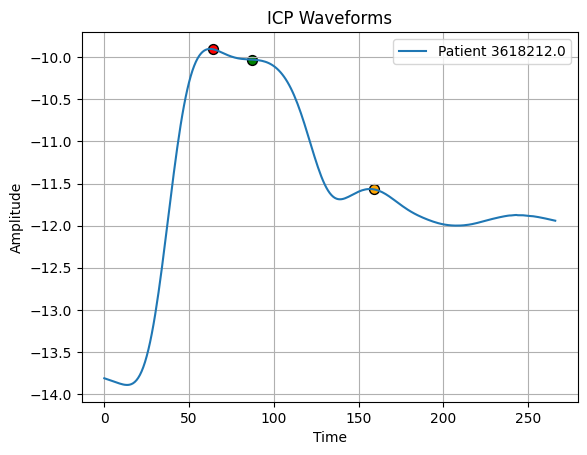

In [3]:
#This is data visualization in matplotlib
#This data visualization is specifically for the training set

import matplotlib.pyplot as plt

icp_wave = trainData[0]['icpWave']  # Extract the icpWave list
plt.plot(icp_wave, label=f'Patient {trainData[0]["patientId"]}')  # Plot each icpWave

# Customize the plot
plt.title('ICP Waveforms')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.scatter(trainData[0]["l1"], icp_wave[round(trainData[0]["l1"])], color='red', label='L1', s=50, edgecolor='black')   
plt.scatter(trainData[0]["l2"], icp_wave[round(trainData[0]["l2"])], color='green', label='L2', s=50, edgecolor='black')   
plt.scatter(trainData[0]["l3"], icp_wave[round(trainData[0]["l3"])], color='orange', label='L3', s=50, edgecolor='black')   

# Show the plot
plt.show()

In [4]:
#Testing the validation set too see if the formatting is all good
file_path = '/kaggle/input/project-1-cosc-220-spring-2025/test.json'
with open(file_path, 'r') as file:
    valData = json.load(file)

# Display the first 5 rows
first_5_rows = valData[:5]  # Slicing the first 5 entries

# Print each row nicely
for i, entry in enumerate(first_5_rows, start=1):
    print(f"Row {i}: {entry}")

Row 1: {'ID': 1, 'patientId': 266092, 'icpWave': [6.290894713354728, 6.262103526552021, 6.23300228656195, 6.203488789460675, 6.17350412932534, 6.142977420588531, 6.1118191402223925, 6.079974828138511, 6.047374197882326, 6.013965833698735, 5.979692620298422, 5.944548077597152, 5.908521898276769, 5.87165121186607, 5.8340071934684765, 5.795707607354814, 5.756913939904314, 5.717836311929819, 5.678714818429752, 5.639876080292105, 5.601657013407658, 5.564446516175105, 5.528693265213664, 5.494862974143145, 5.463494816098272, 5.43514419473272, 5.410419780730921, 5.389979028029009, 5.374479099229561, 5.36466637110782, 5.3612560855711475, 5.364988243646302, 5.37660443884354, 5.396813392186335, 5.42628473111858, 5.465593040884773, 5.515258662337569, 5.575651591862526, 5.647043231434595, 5.7295203139199025, 5.823036294208935, 5.927342028042729, 6.042065829174007, 6.166593868823644, 6.300221728722615, 6.442015115803024, 6.5909661752031905, 6.745872844997628, 6.905493821165992, 7.068443069915044, 7.

In [5]:
file_path = '/kaggle/input/project-1-cosc-220-spring-2025/test.json'
with open(file_path, 'r') as file:
    testData = json.load(file)

# Display the first 5 rows
first_5_rows = trainData[:5]  # Slicing the first 5 entries

# Print each row nicely
for i, entry in enumerate(first_5_rows, start=1):
    print(f"Row {i}: {entry}")

Row 1: {'ID': 8709, 'l1': 64, 'l2': 87, 'l3': 159, 'patientId': 3618212.0, 'icpWave': [-13.811729679237502, -13.818339414747065, -13.825097015692267, -13.831902424786842, -13.839048257620888, -13.846077716758991, -13.85327417764506, -13.860433609649748, -13.867254949532146, -13.873953623993827, -13.879832283321509, -13.884893687083236, -13.888725015767344, -13.890638363979974, -13.890537267270757, -13.887449120705682, -13.880920903399382, -13.870388802126818, -13.854792058629043, -13.833793239544022, -13.8063663692874, -13.771839593684218, -13.729659931159764, -13.678931200222738, -13.619286014566374, -13.55014596594258, -13.471128087975638, -13.38209879835811, -13.282880011957962, -13.173682455608194, -13.054773496691542, -12.926652258658667, -12.790055814157336, -12.645883581504258, -12.495176799905913, -12.339250486369348, -12.179429084162924, -12.017148148539302, -11.85402476107938, -11.691511025224786, -11.531157793584622, -11.374454591694517, -11.222678415277825, -11.077133239831

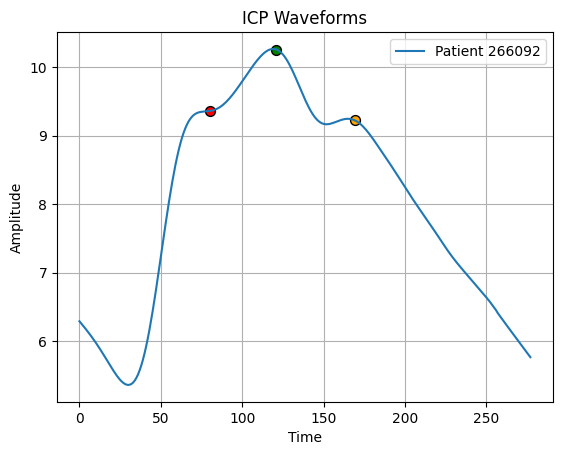

In [6]:
#This is data visualization in matplotlib
#This data visualization is specifically for the validation set

import matplotlib.pyplot as plt

icp_wave = valData[0]['icpWave']  # Extract the icpWave list
plt.plot(icp_wave, label=f'Patient {valData[0]["patientId"]}')  # Plot each icpWave

# Customize the plot
plt.title('ICP Waveforms')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.scatter(val_targets[0]["l1"], icp_wave[round(val_targets[0]["l1"])], color='red', label='L1', s=50, edgecolor='black')   
plt.scatter(val_targets[0]["l2"], icp_wave[round(val_targets[0]["l2"])], color='green', label='L2', s=50, edgecolor='black')   
plt.scatter(val_targets[0]["l3"], icp_wave[round(val_targets[0]["l3"])], color='orange', label='L3', s=50, edgecolor='black')   

# Show the plot
plt.show()

In [7]:
#This is the model

import numpy as np
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler #trying this guy again
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge #trying this thing
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import RidgeCV

# Find the maximum length of icpWave
max_length = max(len(entry['icpWave']) for entry in trainData)


#TRAIN DATA SECTION
# Prepare data
X = []  # Features (icpWave)
y_l1, y_l2, y_l3 = [], [], []  # Targets (l1, l2, l3)

for entry in trainData:
    # Pad or truncate each icpWave to match max_length
    icp_wave = entry['icpWave']
    padded_wave = np.pad(icp_wave, (0, max_length - len(icp_wave)), mode='constant')[:max_length]
    X.append(padded_wave)

    y_l1.append(entry['l1'])  # Append l1 as the target
    y_l2.append(entry['l2'])  # Append l2 as the target
    y_l3.append(entry['l3'])  # Append l3 as the target

# Convert to NumPy arrays
X = np.array(X)
y_l1 = np.array(y_l1)
y_l2 = np.array(y_l2)
y_l3 = np.array(y_l3)

#_______________________________________________________________________________________________________
#EXPERIMENT: finding best alpha value for ridge
ridge_cv = RidgeCV(alphas=[50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100], store_cv_values=True)
ridge_cv.fit(X, y_l1)
ridge_cv.fit(X, y_l2)
ridge_cv.fit(X, y_l3)
print(f"Optimal alpha: {ridge_cv.alpha_}")

# Create a pipeline for each model 
pipeline_l1 = make_pipeline(StandardScaler(), Ridge(alpha=65))
pipeline_l2 = make_pipeline(StandardScaler(), Ridge(alpha=65))
pipeline_l3 = make_pipeline(StandardScaler(), Ridge(alpha=65))
#_______________________________________________________________________________________________________
#EXPERIMENT: Adding Cross Validation
# Define K-Fold Cross-Validation (e.g., 5 folds)
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Perform cross-validation and get the MSE for each fold
scores_l1 = -cross_val_score(pipeline_l1, X, y_l1, cv=kfold, scoring='neg_mean_squared_error')
scores_l2 = -cross_val_score(pipeline_l2, X, y_l2, cv=kfold, scoring='neg_mean_squared_error')
scores_l3 = -cross_val_score(pipeline_l3, X, y_l3, cv=kfold, scoring='neg_mean_squared_error')

print('Here is the Cross Validation Evaluation')
print(f"Cross-Validation MSE for l1: {scores_l1.mean():.4f} ± {scores_l1.std():.4f}")
print(f"Cross-Validation MSE for l2: {scores_l2.mean():.4f} ± {scores_l2.std():.4f}")
print(f"Cross-Validation MSE for l3: {scores_l3.mean():.4f} ± {scores_l3.std():.4f}")
#_______________________________________________________________________________________________________

# Train the models
pipeline_l1.fit(X, y_l1)
pipeline_l2.fit(X, y_l2)
pipeline_l3.fit(X, y_l3)


#VALIDATIION DATA SECTION
#changing the variable names so they don't match with trainData
# Prepare data
Xval = []  # Features (icpWave)
y_val_l1, y_val_l2, y_val_l3 = [], [], []  # Targets (l1, l2, l3)

for entry in valData:
    # Pad or truncate each icpWave to match max_length
    icp_wave = entry['icpWave']
    padded_wave = np.pad(icp_wave, (0, max_length - len(icp_wave)), mode='constant')[:max_length]
    Xval.append(padded_wave)

    y_val_l1.append(val_targets[i]['l1']) #this assigns the target correctly for l1
    y_val_l2.append(val_targets[i]['l2']) #this assigns the target correctly for l2
    y_val_l3.append(val_targets[i]['l3']) #this assigns the target correctly for l3

# Convert validation data to NumPy arrays
Xval = np.array(Xval)
y_val_l1 = np.array(y_val_l1)
y_val_l2 = np.array(y_val_l2)
y_val_l3 = np.array(y_val_l3)

# This predicts on the validation set
y_pred_val_l1 = pipeline_l1.predict(Xval)
y_pred_val_l2 = pipeline_l2.predict(Xval)
y_pred_val_l3 = pipeline_l3.predict(Xval)

# This creates evaluation on the test set using Mean Squared Error (MSE)
#SAVE THIS PART FOR DATA VISUALIZATION
mse_l1 = mean_squared_error(y_val_l1, y_pred_val_l1)
mse_l2 = mean_squared_error(y_val_l2, y_pred_val_l2)
mse_l3 = mean_squared_error(y_val_l3, y_pred_val_l3)


#TEST DATA SECTION
# Prepare test data
Xtest = []  # Features (icpWave)

for entry in testData:
    # Pad or truncate each icpWave to match max_length
    icp_wave = entry['icpWave']
    padded_wave = np.pad(icp_wave, (0, max_length - len(icp_wave)), mode='constant')[:max_length]
    Xtest.append(padded_wave)

# Predict on the test set  
y_pred_l1 = pipeline_l1.predict(Xtest)
y_pred_l2 = pipeline_l2.predict(Xtest)
y_pred_l3 = pipeline_l3.predict(Xtest)

test_df = pd.DataFrame(testData)

output = pd.DataFrame({'ID': test_df["ID"], 
                       'l1': y_pred_l1, 
                       'l2': y_pred_l2, 
                       'l3': y_pred_l3})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Optimal alpha: 65
Here is the Cross Validation Evaluation
Cross-Validation MSE for l1: 28.4035 ± 2.6790
Cross-Validation MSE for l2: 103.3193 ± 11.1996
Cross-Validation MSE for l3: 109.7341 ± 18.1899
Your submission was successfully saved!


In [8]:
#This prints the MSE for the validation set
#Helps evaluate how good we are doing so far

print('Here is the following model evaluation:')
print(f'Validation set MSE for l1: {mse_l1:.3f}')
print(f'Validation set MSE for l2: {mse_l2:.3f}')
print(f'Validation set MSE for l3: {mse_l3:.3f}')

average = (mse_l1 +  mse_l2 + mse_l3) / 3
print(f'Average MSE: {average:.3f}')

Here is the following model evaluation:
Validation set MSE for l1: 79.508
Validation set MSE for l2: 256.885
Validation set MSE for l3: 98.105
Average MSE: 144.833


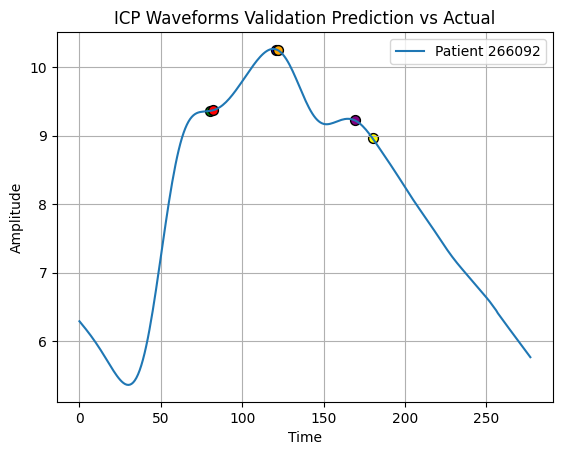

In [9]:
#This is data visualization in matplotlib 
#This visualization is specifically for the Predictions the model made off of the test set

import matplotlib.pyplot as plt

icp_wave = valData[0]['icpWave']  # Extract the icpWave list
plt.plot(icp_wave, label=f'Patient {valData[0]["patientId"]}')  # Plot each icpWave

#Changing the L1, L2, L3 predicted variables so they can be processed correctly in this visualization
predicted_l1 = y_pred_l1[0]
predicted_l2 = y_pred_l2[0]
predicted_l3 = y_pred_l3[0]

#Checking bounds of the waves for predicted values 
predicted_l1_idx = min(max(0, round(predicted_l1)), len(icp_wave) - 1)
predicted_l2_idx = min(max(0, round(predicted_l2)), len(icp_wave) - 1)
predicted_l3_idx = min(max(0, round(predicted_l3)), len(icp_wave) - 1)

# Customize the plot
plt.title('ICP Waveforms Validation Prediction vs Actual')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.scatter(val_targets[0]["l1"], icp_wave[round(val_targets[0]["l1"])], color='green', label='L1', s=50, edgecolor='black')   
plt.scatter(val_targets[0]["l2"], icp_wave[round(val_targets[0]["l2"])], color='blue', label='L2', s=50, edgecolor='black')   
plt.scatter(val_targets[0]["l3"], icp_wave[round(val_targets[0]["l3"])], color='purple', label='L3', s=50, edgecolor='black')   

plt.scatter(predicted_l1, icp_wave[predicted_l1_idx], color='red', label='L1', s=50, edgecolor='black')   
plt.scatter(predicted_l2, icp_wave[predicted_l2_idx], color='orange', label='L2', s=50, edgecolor='black')   
plt.scatter(predicted_l3, icp_wave[predicted_l3_idx], color='yellow', label='L3', s=50, edgecolor='black')    

# Show the plot
plt.show()

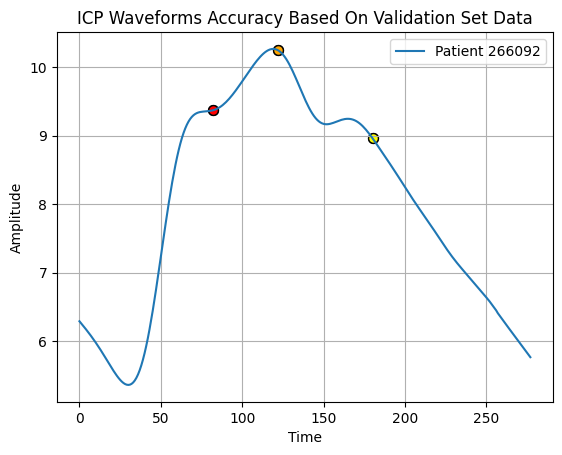

In [10]:
#This is data visualization in matplotlib 
#This visualization is specifically for the Validation predicted vs actual
#I wanted to do this because MSE is just a number, and I am a visual learner!

import matplotlib.pyplot as plt

icp_wave = testData[0]['icpWave']  # Extract the icpWave list
plt.plot(icp_wave, label=f'Patient {testData[0]["patientId"]}')  # Plot each icpWave

#Changing the L1, L2, L3 predicted variables so they can be processed correctly in this visualization
predicted_val_l1 = y_pred_val_l1[0]
predicted_val_l2 = y_pred_val_l2[0]
predicted_val_l3 = y_pred_val_l3[0]

#Checking bounds of the waves for predicted values 
predicted_val_l1_idx = min(max(0, round(predicted_val_l1)), len(icp_wave) - 1)
predicted_val_l2_idx = min(max(0, round(predicted_val_l2)), len(icp_wave) - 1)
predicted_val_l3_idx = min(max(0, round(predicted_val_l3)), len(icp_wave) - 1)

# Customize the plot
plt.title('ICP Waveforms Accuracy Based On Validation Set Data')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.scatter(predicted_val_l1, icp_wave[predicted_val_l1_idx], color='red', label='L1', s=50, edgecolor='black')   
plt.scatter(predicted_val_l2, icp_wave[predicted_val_l2_idx], color='orange', label='L2', s=50, edgecolor='black')   
plt.scatter(predicted_val_l3, icp_wave[predicted_val_l3_idx], color='yellow', label='L3', s=50, edgecolor='black')    

plt.scatter(predicted_val_l1, icp_wave[predicted_val_l1_idx], color='red', label='L1', s=50, edgecolor='black')   
plt.scatter(predicted_val_l2, icp_wave[predicted_val_l2_idx], color='orange', label='L2', s=50, edgecolor='black')   
plt.scatter(predicted_val_l3, icp_wave[predicted_val_l3_idx], color='yellow', label='L3', s=50, edgecolor='black')  

# Show the plot
plt.show()

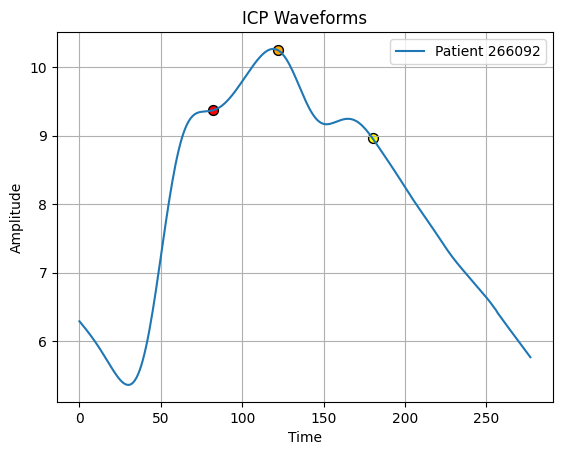

In [11]:
#This is data visualization in matplotlib 
#This visualization is specifically for the Predictions the model made off of the test set

import matplotlib.pyplot as plt

icp_wave = testData[0]['icpWave']  # Extract the icpWave list
plt.plot(icp_wave, label=f'Patient {testData[0]["patientId"]}')  # Plot each icpWave

#Changing the L1, L2, L3 predicted variables so they can be processed correctly in this visualization
predicted_l1 = y_pred_l1[0]
predicted_l2 = y_pred_l2[0]
predicted_l3 = y_pred_l3[0]

#Checking bounds of the waves for predicted values 
predicted_l1_idx = min(max(0, round(predicted_l1)), len(icp_wave) - 1)
predicted_l2_idx = min(max(0, round(predicted_l2)), len(icp_wave) - 1)
predicted_l3_idx = min(max(0, round(predicted_l3)), len(icp_wave) - 1)

# Customize the plot
plt.title('ICP Waveforms')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.scatter(predicted_l1, icp_wave[predicted_l1_idx], color='red', label='L1', s=50, edgecolor='black')   
plt.scatter(predicted_l2, icp_wave[predicted_l2_idx], color='orange', label='L2', s=50, edgecolor='black')   
plt.scatter(predicted_l3, icp_wave[predicted_l3_idx], color='yellow', label='L3', s=50, edgecolor='black')    

# Show the plot
plt.show()

# My model baseline is complete! Let the experimenting begin :)

# Score Sheet!

This note is where I am tracking how the submission scores change based off of what I change/add. 

**Note: if it says "Average MSE" instead of just a score, I didn't submit to competition, I just tested it here with the Validation set**

* Baseline Score: 142.441
* Isolation Forest (Contamination 0.05): 144.029 (0.12  is the best!)
* RobustScaler + PCA + Noise Reduction: 357.916

* Isolation Forest + Noise Reduction
* Window size 5 Average MSE: 168.537
* Window size 10 Average MSE: 167.784
* Window size 20 Average MSE: 165.524
    - It's going down, so something is working!

* RobustScaler (Scaler change): 158.522
* RobustScaler + PCA (n_components=0.95) Average MSE: 79.636 
** Note: my computer proccesses significantly faster and more efficiently ever since adding PCA **
* RobustScaler + PCA (n_components=0.99) Average MSE: 47.806 
* RobustScaler + PCA (n_components=20) Average MSE: 142.743

So turns o

# To Do:

Moral of the story: try stuff, see if it does better or worse, keep moving forward

* note: It said the best alpha for ridge regression was 10 when I did an experiment

* **Next up:** experiment with hyperparameters

Other ideas: 
* If I had more time... try even more different models 

# The Graveyard
All of the methods I tried that DID NOT WORK

* Cross validation (Chloe tried this with me on her code)
* Reduce Overfitting and add noise
* Changing the Kernel in SVR (rbf, C, and gamma made it worse)
* Standardizing Scaling
* KSR (took too much computational power)
* Isolation Forest (made my model too accurate, overfitting isues)
* Noise Reduction (it did ABSOLUTELY NOTHING)
* RobustScaler + PCA combination (MSE got lower in Validation set but it caused a lot of overfitting problems)
* Noise Reduction in waveforms (made it slightly worse)